### LOAN ELIGIBILITY PREDICTION

#### Life Cycle of this ML Project

- 1. Understanding the Problem statement
- 2. Data Collection
- 3. Datachecks to perform
- 4. EDA
- 5. Data Preprocessing
- 6. Model_training
- 7. Choosing best model based on avaluation

##### 1.Problem Statement
- In this we understnads how the approval of loan application gets affected by different features Gender,Marital Status,Education and employment Status,Income ,Loan Amount,Credit History,and Property area.

- importing necessary libraries for EDA
- Understanding the dataset

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


#### Import the dataset as pandas DataFrame


In [8]:
df=pd.read_csv('../data/loan_dataset.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.shape

(614, 13)

##### There are 614 rows(data points) and 13 columns(features) in this particular dataset


In [12]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [39]:
for col in df.columns:
    print(col)
    print(df[col].value_counts())
    

Loan_ID
Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64
Gender
Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
ApplicantIncome
ApplicantIncome
2500     9
4583     6
6000     6
2600     6
3750     5
        ..
7660     1
5955     1
3365     1
2799     1
12841    1
Name: count, Length: 505, dtype: int64
CoapplicantIncome
CoapplicantIncome
0.0       273
1666.0      5
2083.0      5
2500.0      5
1625.0      3
         ... 
2232.0      1
2739.0      1
2210.0      1
461.0       1
2336.0      1
Name: count, Length: 287, d

##### Loan_ID is a just a application Number ,which dont have any affect on approval of Loan for particular appliacnt

In [ ]:
for col in df.columns:
    if col!='Loan_ID':
        print(col)
        
        print(df[col].value_counts())

        print("------")
    

Gender
Gender
Male      489
Female    112
Name: count, dtype: int64
------
Married
Married
Yes    398
No     213
Name: count, dtype: int64
------
Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
------
Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
------
Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
------
ApplicantIncome
ApplicantIncome
2500     9
4583     6
6000     6
2600     6
3750     5
        ..
7660     1
5955     1
3365     1
2799     1
12841    1
Name: count, Length: 505, dtype: int64
------
CoapplicantIncome
CoapplicantIncome
0.0       273
1666.0      5
2083.0      5
2500.0      5
1625.0      3
         ... 
2232.0      1
2739.0      1
2210.0      1
461.0       1
2336.0      1
Name: count, Length: 287, dtype: int64
------
LoanAmount
LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0 

### The features 
- 'Loan_ID'                   - CATEGORICAL,BUT HERE IT IS USELESS
- 'Gender'                    - CATEGORICAL FEATURE
- 'Married'                   - CATEGORICAL FEATURE
- 'Dependents'                - CATEGORICAL FEATURE
- 'Education'                 - CATEGORICAL FEATURE
- 'Self_Employed'             - CATEGORICAL FEATURE
- 'ApplicantIncome'           - NUMERICAL FEATURE
- 'CoapplicantIncome'         - NUMERICAL FEATURE
- 'LoanAmount'                - NUMERICAL FEATURE
- 'Loan_Amount_Term'          - LOOKS NUMERICAL ,BUT ACTUALLY A CATEGORICAL VARIBALE HERE
- 'Credit_History'            - LOOKS NUMERICAL ,BUT ACTUALLY A CATEGORICAL FEATURE
- 'Property_Area'             - CATEGORICAL FEATURE

##### THIS IS OUR TARGET VARIABLE ,,CATEGORICAL TWO CLASSES
- 'Loan_Status'

- this is why it is actually a Binary Classification Problem 


#### there are 12 input features and one output feature which is binary
- the output variable Loan_Status has two values either it approved (Y) or not(N)
- Y → Loan Approved
- N → Loan Rejected

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#### Insights from dataset 
- The dataset contains 13 features including the target variable Loan_Status.
- The target variable indicates whether the loan is approved or rejected,
making this a binary classification problem.

- The dataset contains a mix of categorical and numerical features, with
categorical features being the majority. Therefore, encoding techniques
will be required before training machine learning models.

- The dataset size is relatively small (~600 records), making classical
machine learning algorithms suitable for this task.

#### Chceking whether our dataset has duplicates or not
- here there are no duplicates
- size of the dataset before and after dropping duplicates is same

In [21]:
df.shape

(614, 13)

In [22]:
df.drop_duplicates()

df.shape

(614, 13)

In [31]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [23]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

#### Handling Missing Values 
- Gender - categorical variable ,so replace null values with mode
- Married - catergorical variable ,replacing with mode doesnt affect the dataset much as it is only 3 values
- Dependents -categorical variable , replace with mode
- Self_Employed - categorical variable , replace with mode
- LoanAmount -numerical feature ,here we need to go with median rather than mean ,as median is robust to outliers
- Loan_Amount_Term - Even if it looks like numerical one ,its a categorical feature here ,so here we replace it with mode
- Credit_History- its a categorical variable here - so replace it with mode
 

#### Insights after counting Null Values
- Several columns contain missing values. 
- Categorical features such as Gender, Married, Dependents, and Self_Employed 
will be imputed using the most frequent category.

- Numerical features such as LoanAmount will be imputed using the median to 
reduce the influence of outliers.

- Loan_Amount_Term will be filled with the most frequent value since loan terms 
typically follow standard durations.

- Credit_History contains the highest number of missing values and will be 
imputed using the mode due to its binary nature.

In [30]:
df.head(3)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [46]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

##### Checking whether the dataset is balanced or not
- here ,clearly no of Approvals and no of Rejections is significantly different 


In [65]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [70]:
numerical_features=['ApplicantIncome','CoapplicantIncome', 'LoanAmount']
categorical_features=['Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed','Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


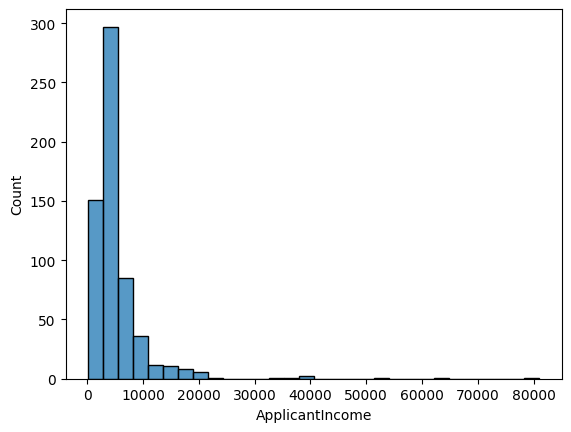

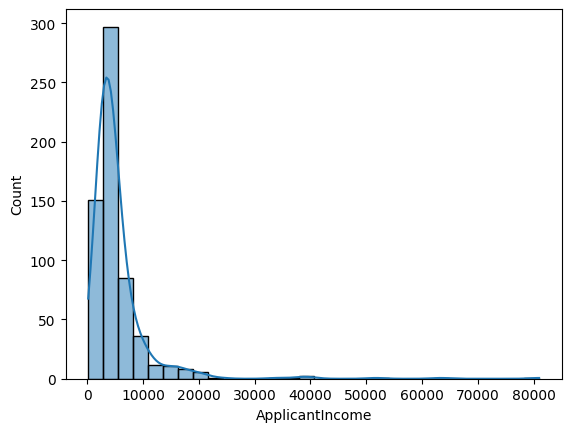

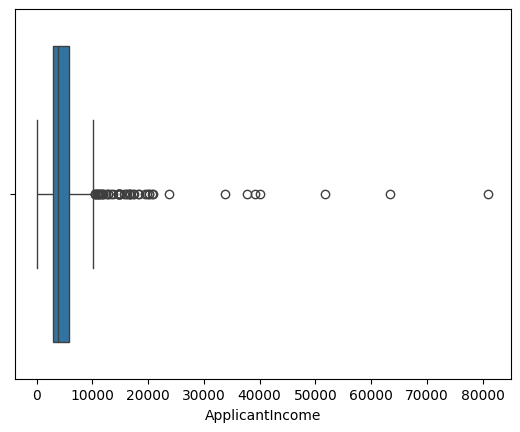

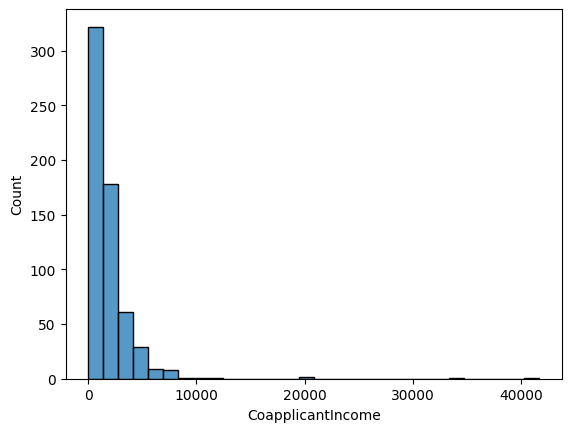

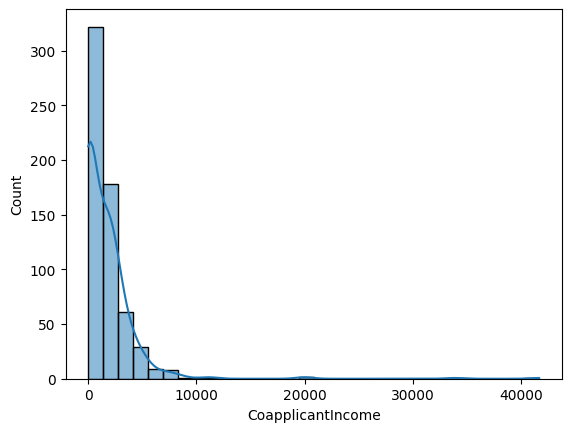

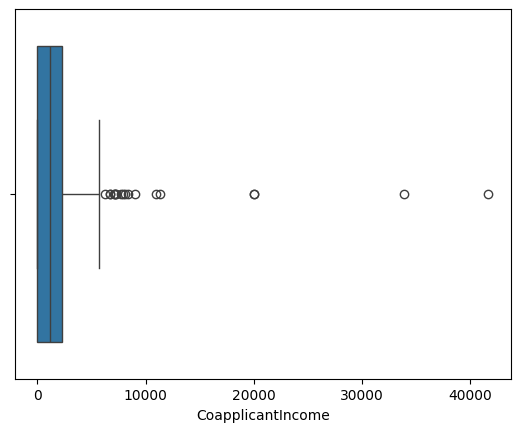

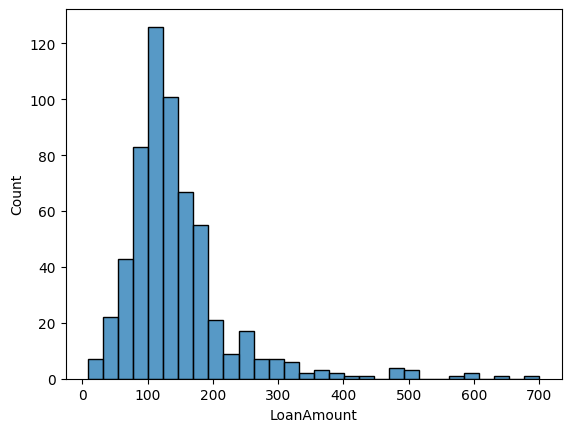

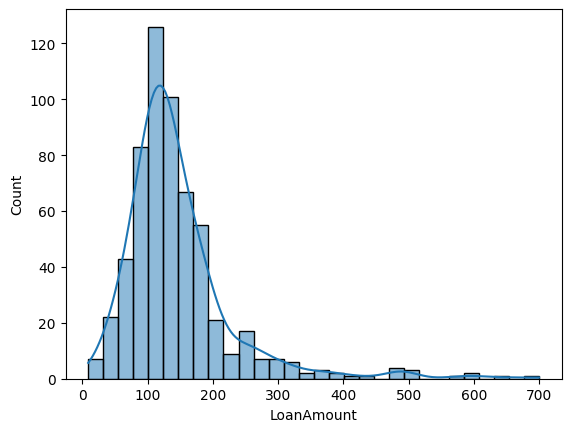

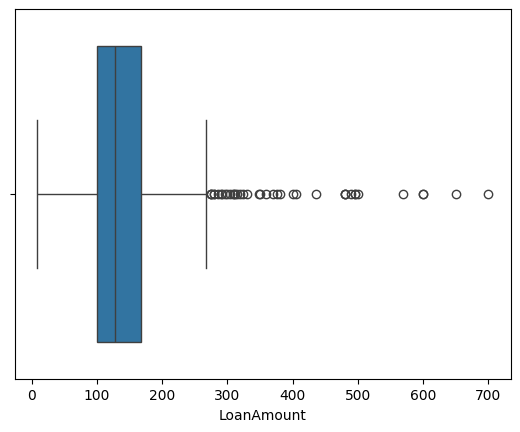

In [73]:
for col in numerical_features:
    sns.histplot(x=df[col],bins=30)
    plt.show()
    sns.histplot(x=df[col],bins=30,kde=True)
    plt.show()
    sns.boxplot(x=df[col])
    plt.show()
    
    

In [76]:
for col in numerical_features:
    print(col,df[col].isnull().sum())

ApplicantIncome 0
CoapplicantIncome 0
LoanAmount 22


- As these numerical features are having outliers ,we use median imputation instead of mean 
- median imputaion is robust to outliers
- here Amonf these three features ,only LoanAmount is having NUll values
- for other two ,we dont need to handle missing values 

In [77]:
print(categorical_features)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


### UNIVARIATE AND MULTIVARIATE ANALYSIS BETWEEN FEATURES

##### Interpreting Gender vs Loan_Status

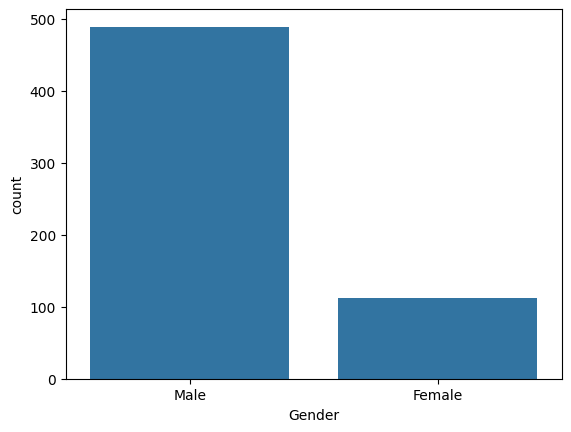

Gender
Male      489
Female    112
Name: count, dtype: int64


In [80]:
sns.countplot(x=df['Gender'])
plt.show()
print(df['Gender'].value_counts())

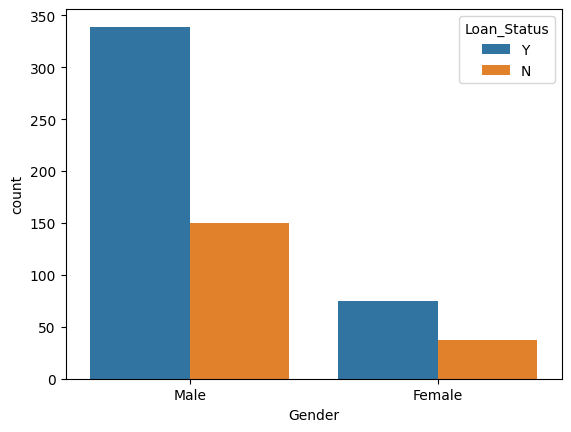

In [84]:
sns.countplot(x=df['Gender'],hue=df['Loan_Status'])
plt.show()


- Most of the applicants are male 
- Even though Male applicants are more ,still we find significant approvals in both genders

##### Interpreting Married vs Loan_Status

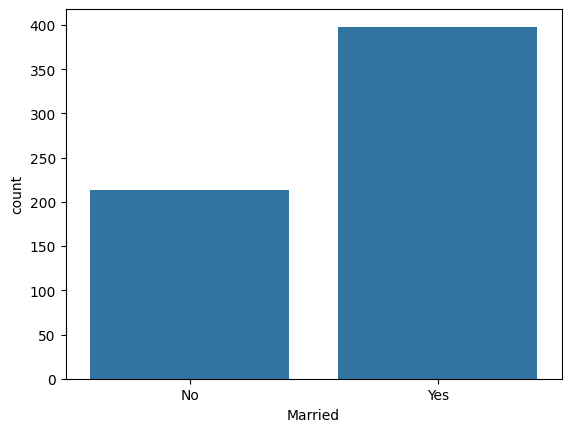

Married
Yes    398
No     213
Name: count, dtype: int64


In [86]:
sns.countplot(x=df['Married'])
plt.show()
print(df['Married'].value_counts())

<Axes: xlabel='Married', ylabel='count'>

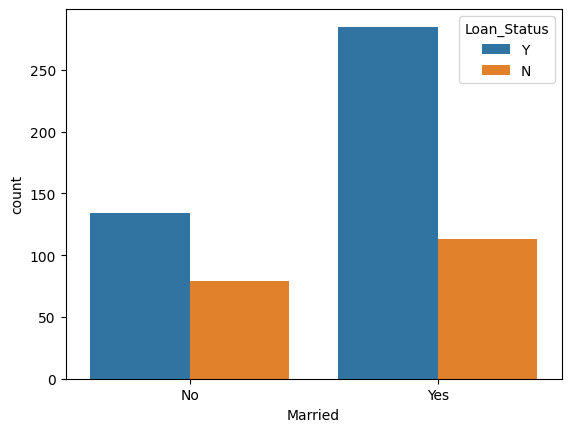

In [87]:
sns.countplot(x=df['Married'],hue=df['Loan_Status'])


- Significant differnce between no of applicants who are married and unmarried
- in both categories ,more than 50 % people got approved their loans

##### Interpreting Dependents vs Loan_Status

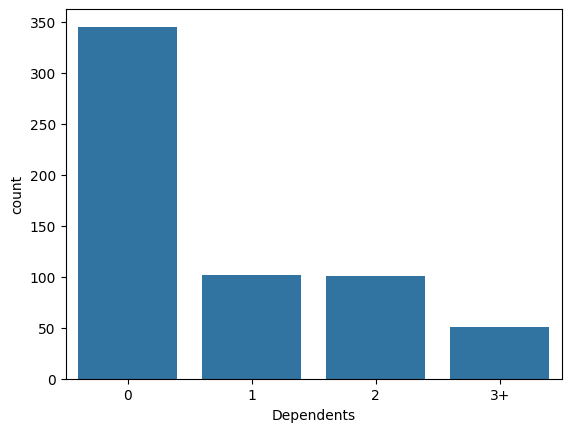

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


In [88]:
sns.countplot(x=df['Dependents'])
plt.show()
print(df['Dependents'].value_counts())

<Axes: xlabel='Dependents', ylabel='count'>

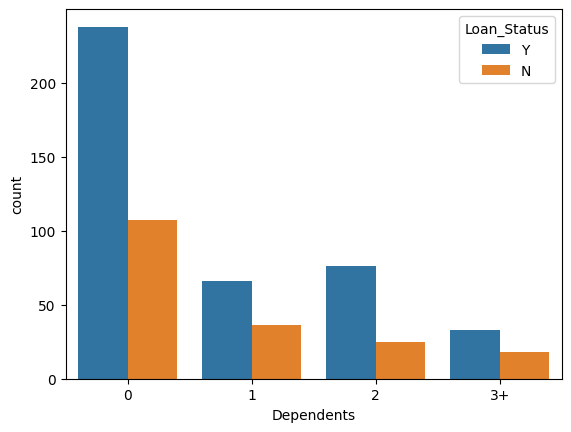

In [89]:
sns.countplot(x=df['Dependents'],hue=df['Loan_Status'])

- Dependent ,this feature is actually about no of people depending on that applicant
- more no of dependents means more expenses 
- This directly replicates the risk of repaymnet 
- Based on the graphs ,more applicants are of having 0 dependents 

##### Interpreting Eductaion vs Loan_Status

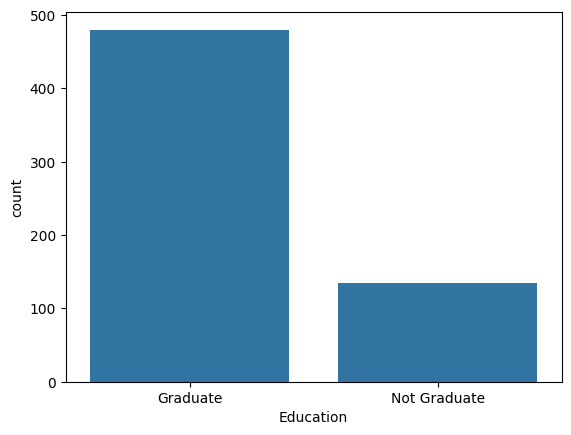

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


In [90]:
sns.countplot(x=df['Education'])
plt.show()
print(df['Education'].value_counts())

<Axes: xlabel='Education', ylabel='count'>

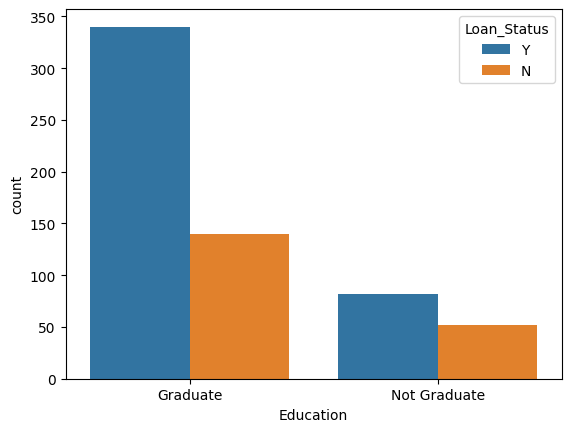

In [91]:
sns.countplot(x=df['Education'],hue=df['Loan_Status'])

- Most of the applicants are graduates here
- Loan approval is slighly depending on these features 
- Basically ,the eduaction showcases thier steady salary,which banks actually needs to check

##### Interpreting Self_Employed vs Loan_Status

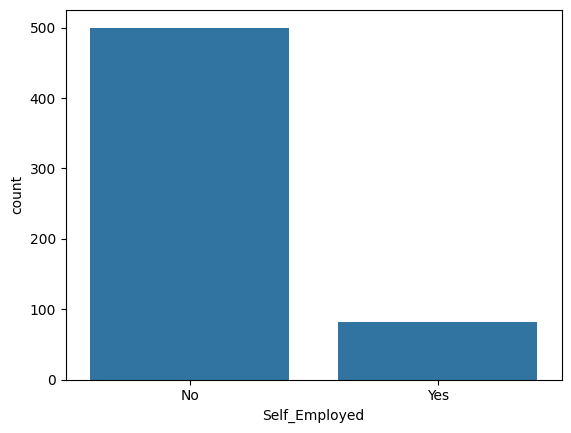

Self_Employed
No     500
Yes     82
Name: count, dtype: int64


In [92]:
sns.countplot(x=df['Self_Employed'])
plt.show()
print(df['Self_Employed'].value_counts())

<Axes: xlabel='Self_Employed', ylabel='count'>

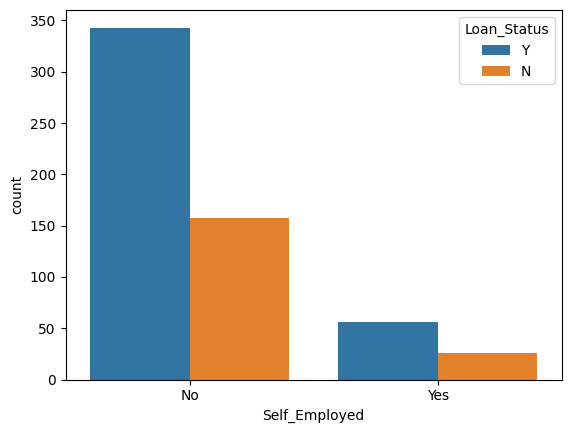

In [93]:
sns.countplot(x=df['Self_Employed'],hue=df['Loan_Status'])

<Axes: xlabel='Self_Employed', ylabel='count'>

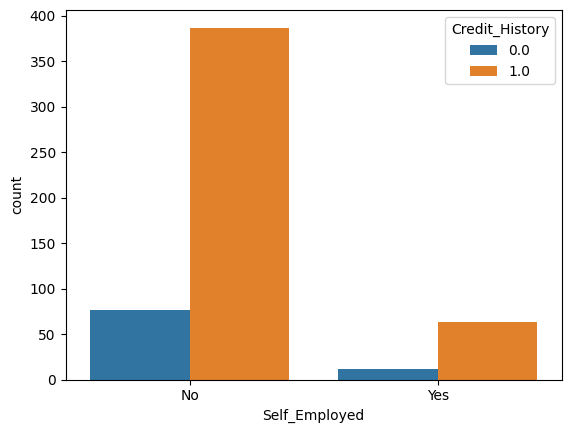

In [94]:
sns.countplot(x=df['Self_Employed'],hue=df['Credit_History'])

- Most of the applicants here are not self employeed
- Even though ,they are not self Employeed ,there are lot of members got approval for thier Loan_Applictaion
- When we look into 3rd plot here ,Even though they are not self Employeed ,becasue of thier credibility(Credit_History) they got thier application Approved..proving Credit History is one of the Major Criteria for Approval


In [95]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

##### Interpreting Property Area vs Loan_Status

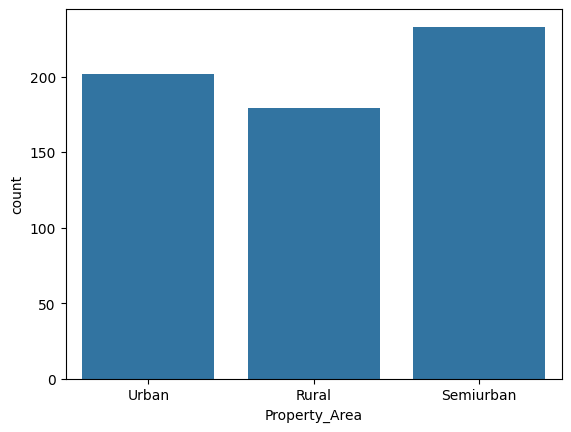

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


In [96]:
sns.countplot(x=df['Property_Area'])
plt.show()
print(df['Property_Area'].value_counts())

<Axes: xlabel='Property_Area', ylabel='count'>

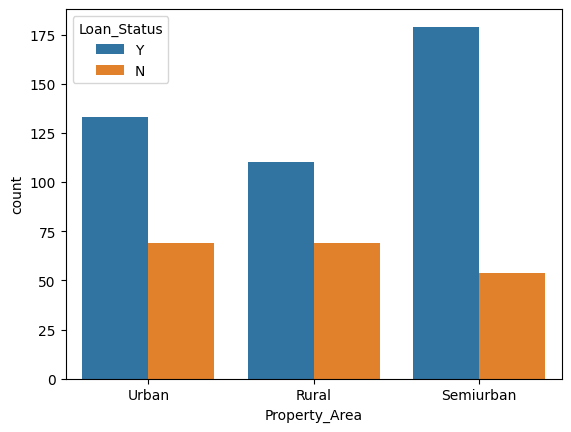

In [97]:
sns.countplot(x=df['Property_Area'],hue=df['Loan_Status'])

<Axes: xlabel='Property_Area', ylabel='count'>

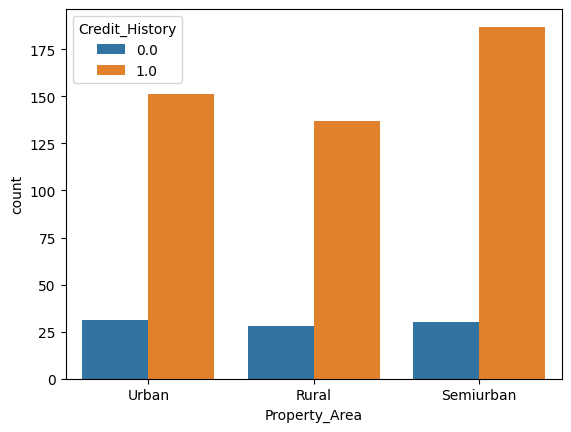

In [98]:
sns.countplot(x=df['Property_Area'],hue=df['Credit_History'])

- There is no significant difference between no of applicants having thier property in differnt aread
- here ,there is slight differencr in Rejecting the appliactions of Rural_Area
- Based on their CRedit History ,every area falls under good 

##### Interpreting the Credit_History vs Loan_Status

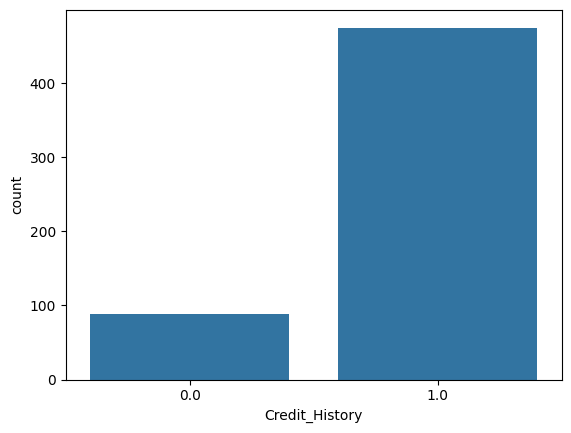

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


In [100]:
sns.countplot(x=df['Credit_History'])
plt.show()
print(df['Credit_History'].value_counts())

<Axes: xlabel='Credit_History', ylabel='count'>

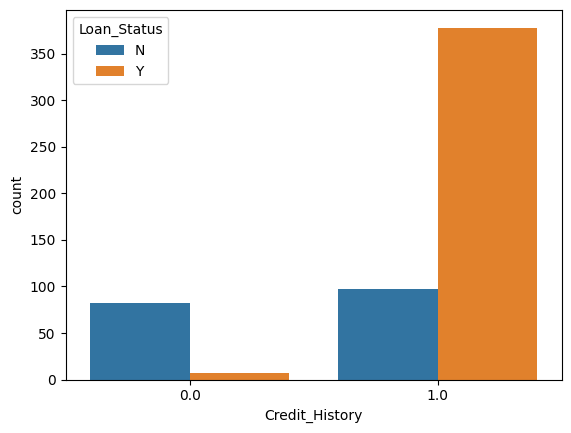

In [101]:
sns.countplot(x=df['Credit_History'],hue=df['Loan_Status'])

- This is one of the Major Feature 
- Most of them ,whose credit score is good ,they got approval
- Whose credit_score is less ,they got more Rejection swhich is totallty fair

##### Interpreting Loan_Anount_Term vs Loan_Status

In [104]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

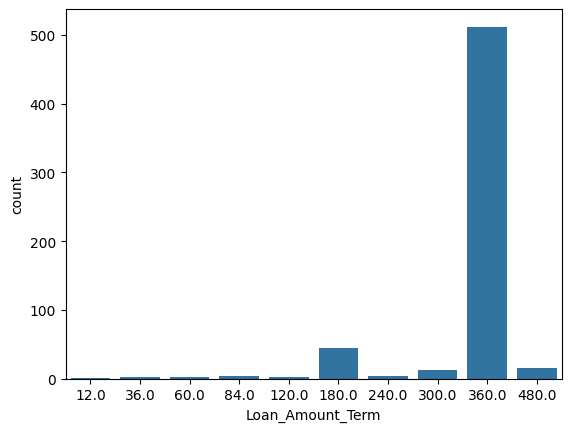

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


In [105]:
sns.countplot(x=df['Loan_Amount_Term'])
plt.show()
print(df['Loan_Amount_Term'].value_counts())

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

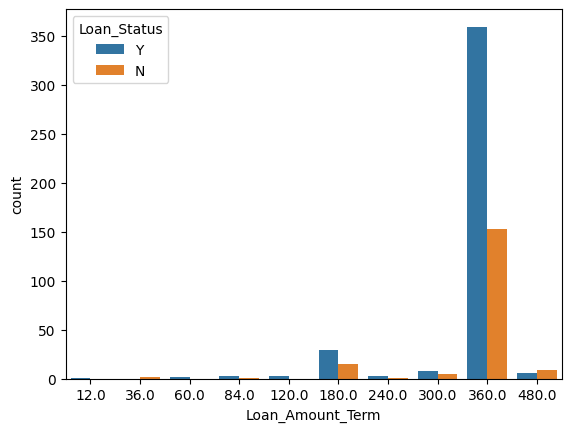

In [106]:
sns.countplot(x=df['Loan_Amount_Term'],hue=df['Loan_Status'])

- Most of the people opted fot 360 month tenure ,which is 30 years 
- here we are having 10 set of values
- even though it looks numerical,its actually a categorical variable 


In [107]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

##### Interpreting ApplicantIncome vs Loan_Status

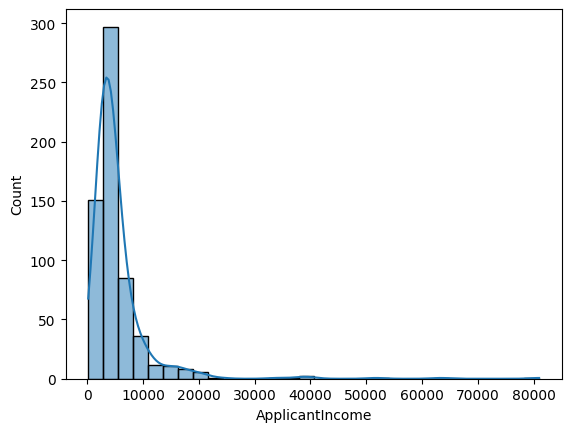

ApplicantIncome
2500     9
4583     6
6000     6
2600     6
3750     5
        ..
7660     1
5955     1
3365     1
2799     1
12841    1
Name: count, Length: 505, dtype: int64


In [112]:
sns.histplot(x=df['ApplicantIncome'],bins=30,kde=True)
plt.show()
print(df['ApplicantIncome'].value_counts())

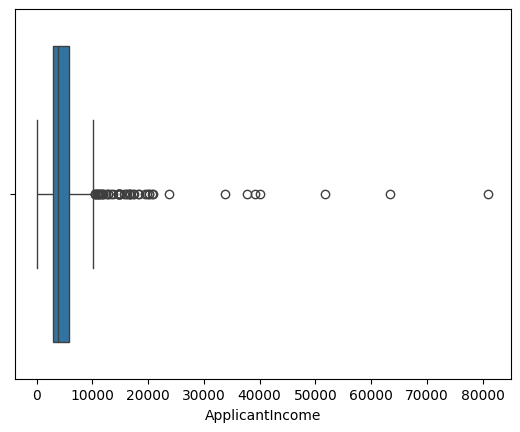

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

In [116]:
sns.boxplot(x=df['ApplicantIncome'])
plt.show()
df['ApplicantIncome'].describe()

<Axes: xlabel='ApplicantIncome', ylabel='Loan_Status'>

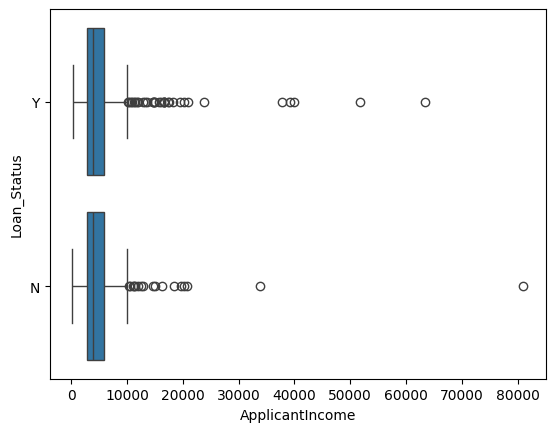

In [113]:
sns.boxplot(x=df['ApplicantIncome'],y=df['Loan_Status'],data=df)

- Numerical Feature
- there are outliers in this particular column
- Here the Income plot is rigth skewed which tells us , very few people are having higher income
- most applicants Income lies between 0 and 20,000

##### Interpreting CoapplicantIncome vs Loan_Status

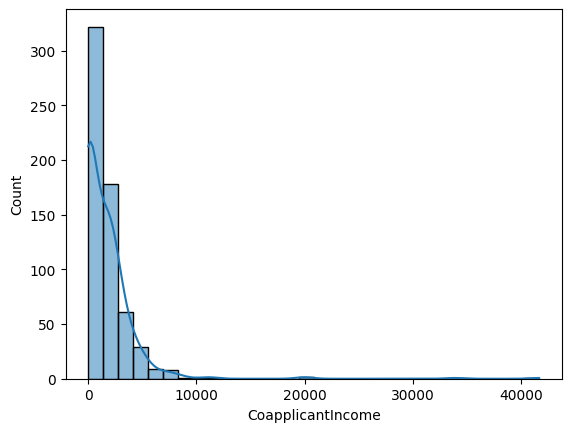

CoapplicantIncome
0.0       273
1666.0      5
2083.0      5
2500.0      5
1625.0      3
         ... 
2232.0      1
2739.0      1
2210.0      1
461.0       1
2336.0      1
Name: count, Length: 287, dtype: int64


In [117]:
sns.histplot(x=df['CoapplicantIncome'],bins=30,kde=True)
plt.show()
print(df['CoapplicantIncome'].value_counts())

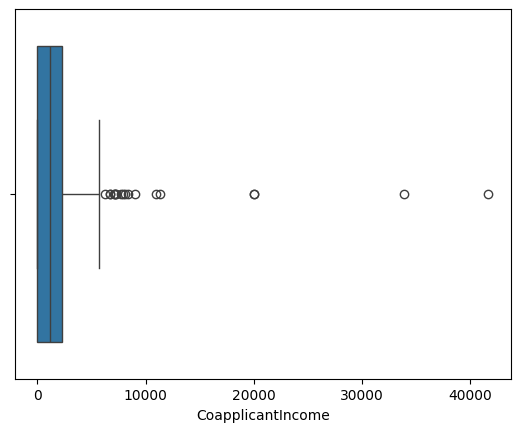

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

In [120]:
sns.boxplot(x=df['CoapplicantIncome'])
plt.show()
df['CoapplicantIncome'].describe()


<Axes: xlabel='CoapplicantIncome', ylabel='Loan_Status'>

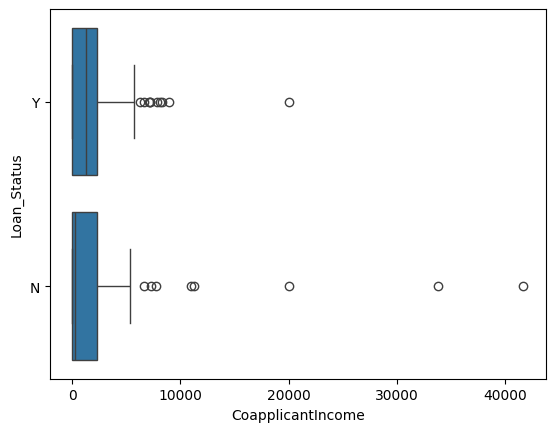

In [121]:
sns.boxplot(x=df['CoapplicantIncome'],y=df['Loan_Status'],data=df)

- Having outliers
- Right skewed pplot indicating very few people have high income 
-  most of the people's Income ranges from 0 to 10000
- Here ,MEdian of Approved Coapplicants income more than median of REjected CoapplicantIncome



##### Interpreting Loan_Amount vs Loan_Status

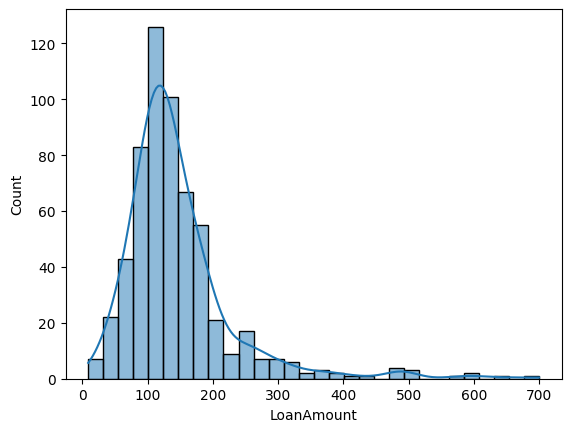

LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 203, dtype: int64


In [123]:
sns.histplot(x=df['LoanAmount'],bins=30,kde=True)
plt.show()
print(df['LoanAmount'].value_counts())

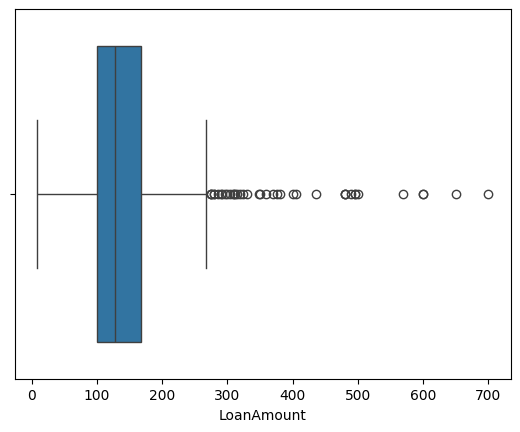

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [125]:
sns.boxplot(x=df['LoanAmount'])
plt.show()
df['LoanAmount'].describe()

<Axes: xlabel='LoanAmount', ylabel='Loan_Status'>

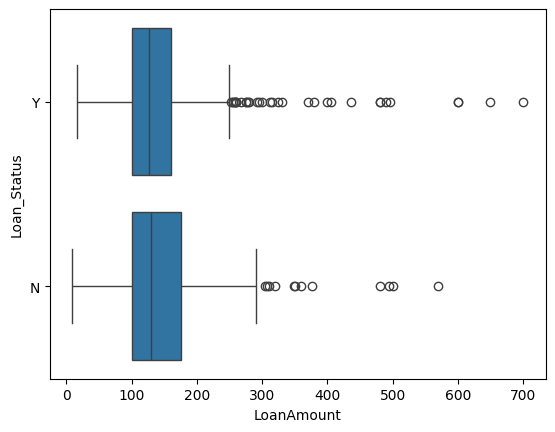

In [126]:
sns.boxplot(x=df['LoanAmount'],y=df['Loan_Status'],data=df)

- having outliers
- as this feature already having null values
- if we want fill values ,we have to go with median
- Median is robust to outliers rather than mean
- Most of the peoples loan amount is ranging from 0 to 300k
- here ,Median of both Approved and Rejected is simliar 
- the varaition in Loan_amounts in Rejections is large compared ot Approvals


#### Credit history shows a strong positive relationship with loan approval.
#### Applicants with a prior credit record are overwhelmingly approved,indicating that lenders rely heavily on past repayment behavior when making decisions.
